# Value at Risk Analysis
This notebook explores different approaches to modelling variance in the DK1 area (Danish mainland) power markets' daily peak mean prices (08:00 to 20:00 Copenhagen Local Time). 


## Module Imports and Data Processing

In [52]:
from varkit.data import fetch_spot_price, daily_peak_mean
from varkit.var import historical_var
import pandas as pd
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

In [59]:
end=(pd.Timestamp('2026-08-19').date())
start=end-pd.Timedelta(days=(322))
prices=fetch_spot_price(area='DK1', start=start, end=end)
daily=daily_peak_mean(prices)
pnl=daily.diff().dropna()
N=len(pnl)
print(f"{N} observations available from {start} to {end}")

321 observations available from 2025-10-01 to 2026-08-19


# Exploratory Data Analysis

The profit and loss series is first modelled using a fitted normal distribution fitted to the data, before using a historical approach.


In [56]:
pnl_mean=np.mean(pnl)
pnl_sd=np.std(pnl)
norm_pnl=norm(pnl_mean,pnl_sd)

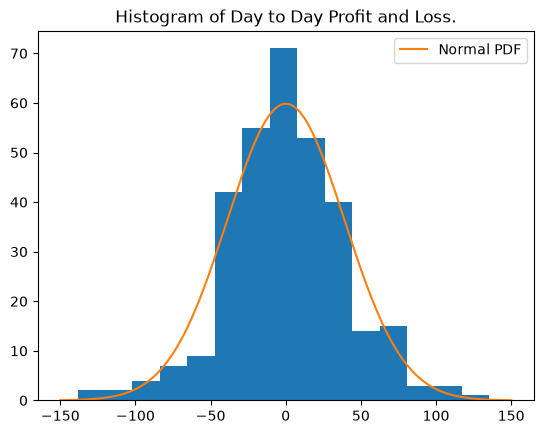

In [64]:
nbins=15
plt.hist(pnl, bins=nbins)

bin_width=(pnl.max()-pnl.min())/nbins
xspace=np.linspace(-150,150, 1000)
plt.plot(xspace, norm_pnl.pdf(xspace)*N*bin_width, label='Normal PDF')
plt.title('Histogram of Day to Day Profit and Loss.')
plt.legend()
plt.show()

In [117]:
norm25=norm_pnl.ppf(0.25)
norm15=norm_pnl.ppf(0.15)
norm05=norm_pnl.ppf(0.05)
norm01=norm_pnl.ppf(0.01)
norm005=norm_pnl.ppf(0.005)
norm0005=norm_pnl.ppf(0.0005)

In [132]:

for p,val in zip([25,15,5,1,0.5,0.05],[norm25,norm15,norm05, norm01, norm005,norm0005]):
    print(f"% of values below the {p}th percentile (€{val:.2f})")
    print(f"Expected: {p/100:.2%}")
    print(f"Actual: {(len(pnl.loc[pnl<val])/len(pnl)):.2%}")



% of values below the 25th percentile (€-26.29)
Expected: 25.00%
Actual: 22.74%
% of values below the 15th percentile (€-40.44)
Expected: 15.00%
Actual: 11.21%
% of values below the 5th percentile (€-64.23)
Expected: 5.00%
Actual: 4.98%
% of values below the 1th percentile (€-90.88)
Expected: 1.00%
Actual: 1.87%
% of values below the 0.5th percentile (€-100.64)
Expected: 0.50%
Actual: 1.25%
% of values below the 0.05th percentile (€-128.58)
Expected: 0.05%
Actual: 0.62%


While the normal distribution seems to fit the data reasonably well, the values above show an overestimation of probability closer to the mean, and a heavy underestimation at the tails (The normal underestimates the probability of a loss of €128 or greater by a factor of 12). 

To avoid this, we can implement a nonparametric approach which doesn't assume a distribution by only using historical data.

In [114]:
his_var95=historical_var(pnl, alpha=0.95)
his_var99=historical_var(pnl, alpha=0.99)
his_var995=historical_var(pnl, alpha=0.995)

In [ ]:
print("| alpha | Historical Estimate| Fitted Normal Estimate |")
print("| --- | --- | --- |")
for his, norm, val in zip((his_var95, his_var99, his_var995),(norm05,norm01,norm005),(0.95,0.99,0.995)):
    print(f"| {val:.1%} | €{his:.2f} | €{-norm:.2f} |")


| alpha | Historical Estimate| Standard Normal Estimate |
| --- | --- | --- |
| 95.0% | €57.01 | €64.23 |
| 99.0% | €104.54 | €90.88 |
| 99.5% | €129.61 | €100.64 |


There are several advantages and disadvantages to implementing this approach, the primary advantage being fair estimation of probability of tail events. 

However, there are also limitations to this estimates given from this method. Firstly, the values at the tails can differ by almost €10/MWh, and since this is an order-statistic and given a small enough sample size(N=321), 1 extra observation can move the estimated Value at Risk significantly. This method also assumes volatility in the power markets is stable and deviations are drawn from the same distribution, which is extremely unlikely given the known heteroskedacity of these markets. 